# How well do jobs and skills pay  for Data Analysts?
### Methodology
- Evaluate the median Salary for top 6 data analysts jobs
- Find median salary per skill for Data Analysts
- Visualize foe highest paying skills and most demanded skills

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('../data_jobs.csv')


# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_india = df[df['job_country'] == 'India'].dropna(subset='salary_year_avg').copy()

In [9]:
 job_titles = df_india['job_title_short'].value_counts().index[:6].tolist()

In [11]:
df_india_top6 = df_india[df_india['job_title_short'].isin(job_titles)]

In [16]:
job_order = df_india_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

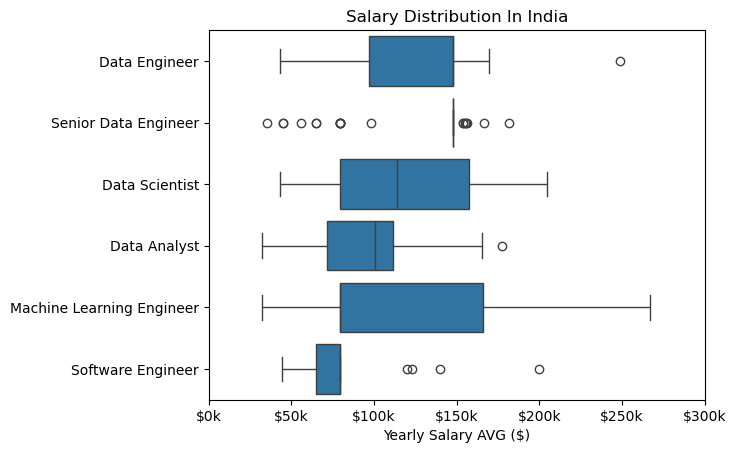

In [20]:
sns.boxplot(data =df_india_top6, x = 'salary_year_avg', y='job_title_short', order=job_order)

plt.title('Salary Distribution In India')
plt.ylabel('')
plt.xlabel('Yearly Salary AVG ($)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 300_000)
plt.show()

## Investigate Median Salary VS Skill for Data Analysts

In [3]:
# Only USA Data Enginers role
df_DE_india = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()
df_DE_india = df_DE_india.dropna(subset=['salary_year_avg'])

In [4]:
df_DE_india = df_DE_india.explode('job_skills')

In [ ]:
df_top_pay = df_DE_india.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False)
df_top_pay = df_top_pay.head(10)

,count,median
job_skills,,
mongo,78,208114.0
vue,1,200000.0
solidity,1,192500.0
node,24,190000.0
ggplot2,2,176250.0
macos,2,172000.0
clojure,2,170866.5
atlassian,18,169860.0
rust,7,165000.0


In [40]:
df_top_skills = df_DE_india.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_top_skills = df_top_skills.head(10)

df_top_skills = df_top_skills.sort_values(by='median', ascending=False)
df_top_skills

,count,median
job_skills,,
kafka,536,145000.00000
nosql,519,140000.00000
spark,968,137410.15625
java,732,137000.00000
redshift,514,135000.00000
aws,1313,131000.00000
snowflake,765,130700.00000
python,2007,127794.50000
sql,2110,125000.00000


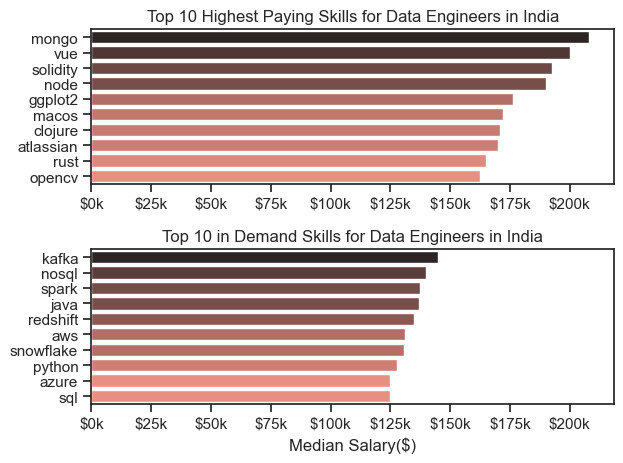

In [39]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style="ticks")

sns.barplot(data=df_top_pay, x='median', y=df_top_pay.index, ax=ax[0], hue='median', palette='dark:salmon_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paying Skills for Data Engineers in India')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))


sns.barplot(data=df_top_skills, x='median', y=df_top_skills.index, ax=ax[1], hue='median', palette='dark:salmon_r')
ax[1].legend().remove()
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 in Demand Skills for Data Engineers in India')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary($)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.tight_layout()